<a href="https://colab.research.google.com/github/Dathu-03184/DL_Lab-Programs/blob/main/01%20program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Bi-Level (Binary) Confusion Matrix ===
                     Pred: Healthy (0)  Pred: TB (1)
Actual: Healthy (0)                  3             1
Actual: TB (1)                       1             3

Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.75      0.75      0.75         8
weighted avg       0.75      0.75      0.75         8



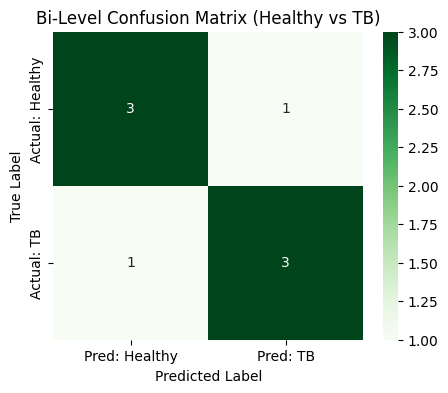


=== Multi-Level (Multi-Class) Confusion Matrix ===
                       Pred: Healthy (0)  Pred: Pneumonia (1)  Pred: TB (2)
Actual: Healthy (0)                    2                    0             1
Actual: Pneumonia (1)                  0                    2             1
Actual: TB (2)                         1                    1             2

Accuracy: 0.6

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.67      0.67      0.67         3
           2       0.50      0.50      0.50         4

    accuracy                           0.60        10
   macro avg       0.61      0.61      0.61        10
weighted avg       0.60      0.60      0.60        10



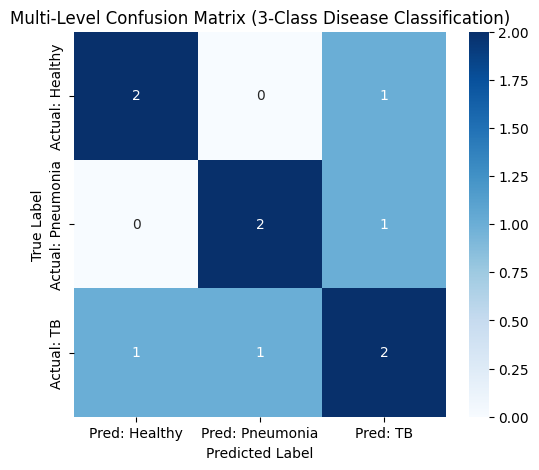

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

y_true_binary = [0, 1, 0, 1, 0, 1, 1, 0]
y_pred_binary = [0, 1, 0, 0, 0, 1, 1, 1]

cm_binary = confusion_matrix(y_true_binary, y_pred_binary)
acc_binary = accuracy_score(y_true_binary, y_pred_binary)

# Display Table
print("=== Bi-Level (Binary) Confusion Matrix ===")
print(pd.DataFrame(cm_binary,
                   index=["Actual: Healthy (0)", "Actual: TB (1)"],
                   columns=["Pred: Healthy (0)", "Pred: TB (1)"]))

print("\nAccuracy:", round(acc_binary, 3))
print("\nClassification Report:\n", classification_report(y_true_binary, y_pred_binary))

plt.figure(figsize=(5, 4))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred: Healthy", "Pred: TB"],
            yticklabels=["Actual: Healthy", "Actual: TB"])
plt.title("Bi-Level Confusion Matrix (Healthy vs TB)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

y_true_multi = [0, 1, 2, 2, 0, 1, 2, 1, 0, 2]
y_pred_multi = [0, 2, 1, 2, 0, 1, 0, 1, 2, 2]

cm_multi = confusion_matrix(y_true_multi, y_pred_multi)
acc_multi = accuracy_score(y_true_multi, y_pred_multi)

print("\n=== Multi-Level (Multi-Class) Confusion Matrix ===")
print(pd.DataFrame(cm_multi,
                   index=["Actual: Healthy (0)", "Actual: Pneumonia (1)", "Actual: TB (2)"],
                   columns=["Pred: Healthy (0)", "Pred: Pneumonia (1)", "Pred: TB (2)"]))

print("\nAccuracy:", round(acc_multi, 3))
print("\nClassification Report:\n", classification_report(y_true_multi, y_pred_multi))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: Healthy", "Pred: Pneumonia", "Pred: TB"],
            yticklabels=["Actual: Healthy", "Actual: Pneumonia", "Actual: TB"])
plt.title("Multi-Level Confusion Matrix (3-Class Disease Classification)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


=== Overfitting Example (Polynomial Regression) ===
Train MSE: 0.00389027085514378
Test MSE:  0.010724709996595161
Train R² : 0.9926296660629342
Test R²  : 0.9779133015852656


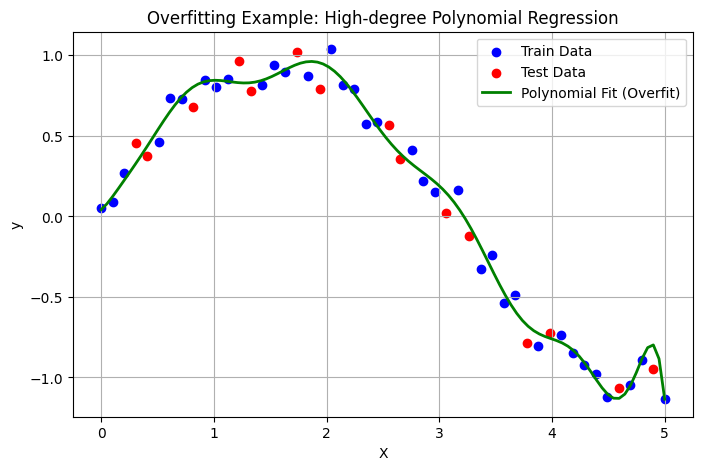

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# -------------------------------
# 1️⃣ Generate synthetic data (non-linear)
# -------------------------------
np.random.seed(42)
X = np.linspace(0, 5, 50).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])  # sine wave + noise

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -------------------------------
# 2️⃣ Fit a high-degree Polynomial Regression (Overfitting)
# -------------------------------
poly = PolynomialFeatures(degree=15)  # Very high degree → overfitting
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

# -------------------------------
# 3️⃣ Evaluate Overfitting
# -------------------------------
print("=== Overfitting Example (Polynomial Regression) ===")
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE: ", mean_squared_error(y_test, y_test_pred))
print("Train R² :", r2_score(y_train, y_train_pred))
print("Test R²  :", r2_score(y_test, y_test_pred))

# -------------------------------
# 4️⃣ Visualization
# -------------------------------
plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.plot(np.linspace(0,5,100).reshape(-1,1),
         model.predict(poly.transform(np.linspace(0,5,100).reshape(-1,1))),
         color='green', linewidth=2, label='Polynomial Fit (Overfit)')
plt.title("Overfitting Example: High-degree Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


=== Linear Regression Performance ===
Train MSE: 3854.113
Test MSE:  4061.826
Train R²:  0.366
Test R²:   0.233


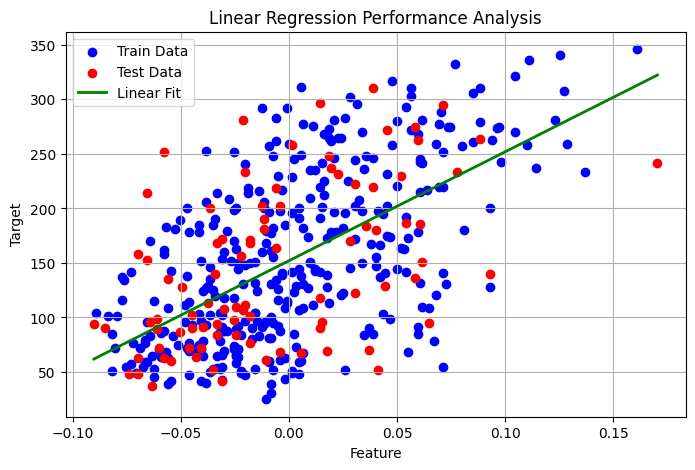

In [11]:
# ================================================
# Linear Regression Performance Analysis using Diabetes Dataset
# ================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1️⃣ Load Dataset
data = load_diabetes()
X = data.data[:, 2].reshape(-1, 1)  # Use one feature for simplicity
y = data.target

# 2️⃣ Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3️⃣ Train Linear Regression model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# 4️⃣ Predict on train and test sets
y_train_pred = lin_model.predict(X_train)
y_test_pred = lin_model.predict(X_test)

# 5️⃣ Evaluate Performance
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=== Linear Regression Performance ===")
print(f"Train MSE: {train_mse:.3f}")
print(f"Test MSE:  {test_mse:.3f}")
print(f"Train R²:  {train_r2:.3f}")
print(f"Test R²:   {test_r2:.3f}")

# 6️⃣ Visualization
plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.plot(np.sort(X, axis=0), lin_model.predict(np.sort(X, axis=0)), color='green', linewidth=2, label='Linear Fit')
plt.title("Linear Regression Performance Analysis")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.grid(True)
plt.show()


=== Logistic Regression Performance ===
Accuracy: 0.956

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



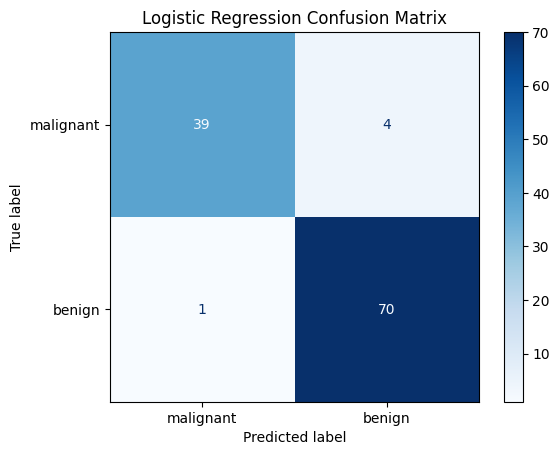

In [12]:
# ================================================
# Logistic Regression Performance Analysis using Breast Cancer Dataset
# ================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1️⃣ Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2️⃣ Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3️⃣ Train Logistic Regression model
log_model = LogisticRegression(max_iter=10000)
log_model.fit(X_train, y_train)

# 4️⃣ Predict on test set
y_pred = log_model.predict(X_test)

# 5️⃣ Evaluate Performance
accuracy = accuracy_score(y_test, y_pred)
print("=== Logistic Regression Performance ===")
print(f"Accuracy: {accuracy:.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# 6️⃣ Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


Gradient Descent Result:
Estimated intercept: 4.215
Estimated slope:     2.770
Final MSE:           0.807


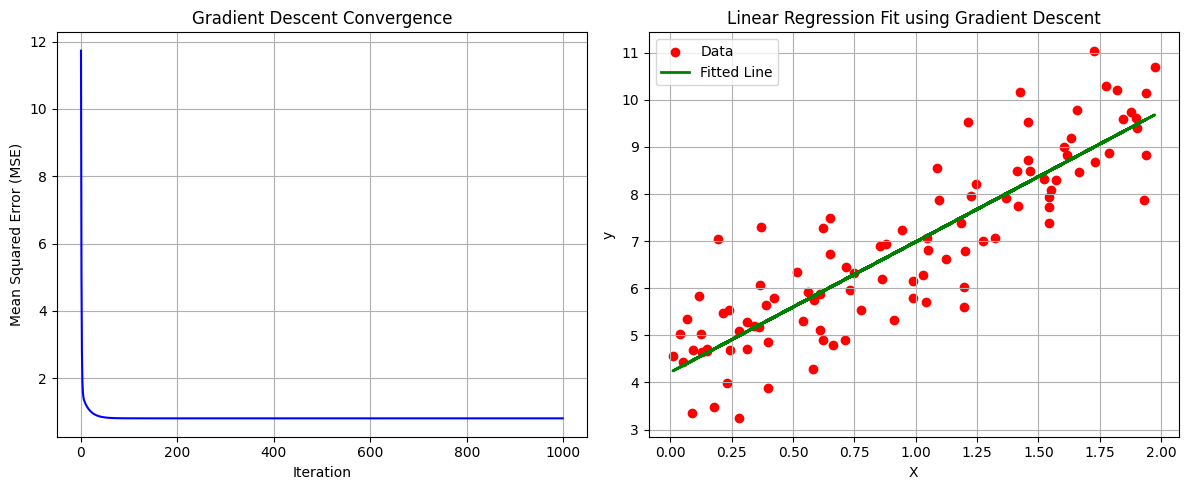

In [13]:
# ================================================
# Demonstrating Gradient Descent Performance
# ================================================

import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Generate synthetic linear data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # y = 4 + 3x + noise

# 2️⃣ Initialize parameters
theta = np.random.randn(2,1)  # [intercept, slope]
learning_rate = 0.1
n_iterations = 1000
m = len(X)

# Add bias term (x0 = 1)
X_b = np.c_[np.ones((m,1)), X]

# Store loss for visualization
loss_history = []

# 3️⃣ Gradient Descent Algorithm
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - learning_rate * gradients
    loss = np.mean((X_b.dot(theta) - y)**2)
    loss_history.append(loss)

# 4️⃣ Output results
print("Gradient Descent Result:")
print(f"Estimated intercept: {theta[0][0]:.3f}")
print(f"Estimated slope:     {theta[1][0]:.3f}")
print(f"Final MSE:           {loss_history[-1]:.3f}")

# 5️⃣ Visualization of Gradient Descent Performance

# Loss curve
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(n_iterations), loss_history, color='blue')
plt.title("Gradient Descent Convergence")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)

# Fitted line vs data
plt.subplot(1,2,2)
plt.scatter(X, y, color='red', label="Data")
plt.plot(X, X_b.dot(theta), color='green', linewidth=2, label="Fitted Line")
plt.title("Linear Regression Fit using Gradient Descent")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


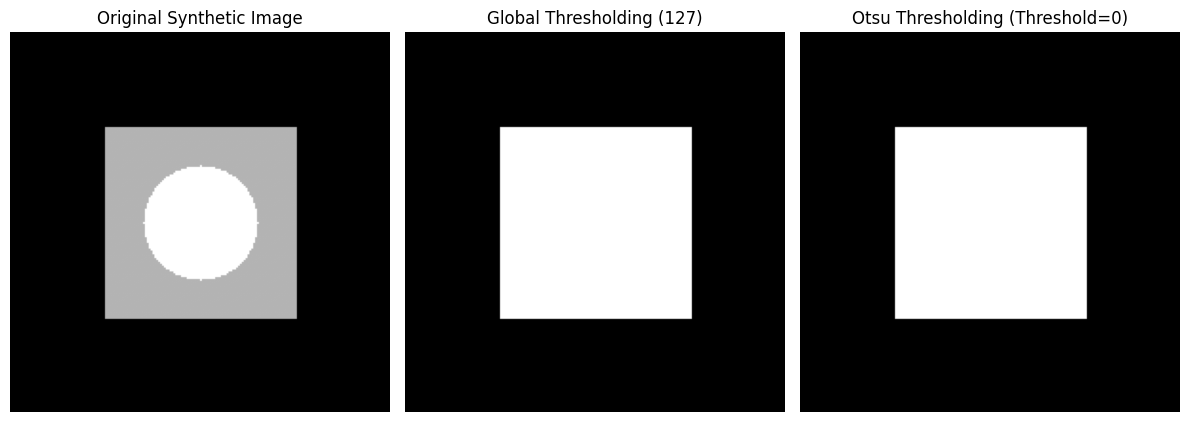

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Create a synthetic grayscale image (bimodal)
# Black background + white rectangle
img = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img, (50, 50), (150, 150), 180, -1)  # gray rectangle
cv2.circle(img, (100, 100), 30, 255, -1)           # white circle inside rectangle

# 2️⃣ Apply global thresholding (fixed threshold)
_, thresh_global = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 3️⃣ Apply Otsu's thresholding (automatic)
_, thresh_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4️⃣ Visualization
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original Synthetic Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(thresh_global, cmap='gray')
plt.title('Global Thresholding (127)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(thresh_otsu, cmap='gray')
plt.title(f'Otsu Thresholding (Threshold={_:.0f})')
plt.axis('off')

plt.tight_layout()
plt.show()


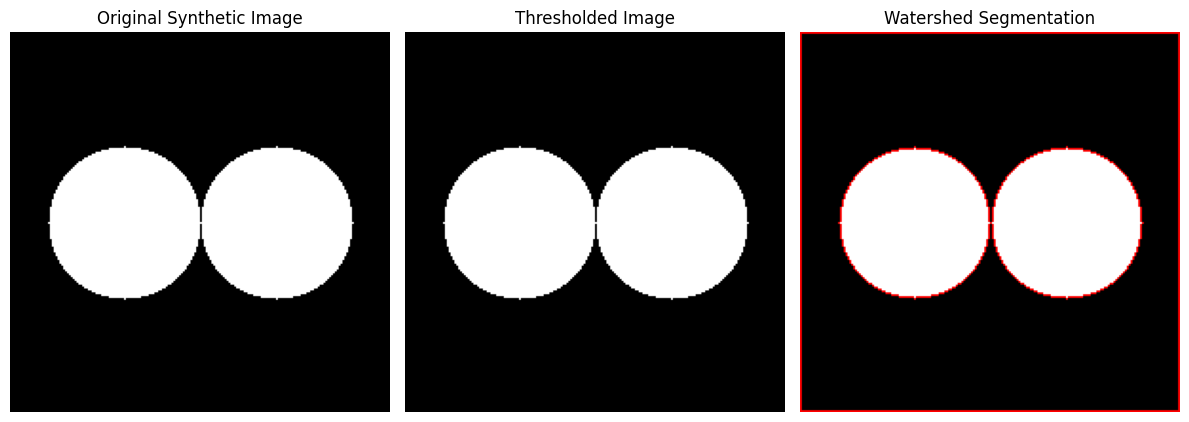

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Create synthetic image with overlapping circles
img = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img, (60, 100), 40, 255, -1)
cv2.circle(img, (140, 100), 40, 255, -1)

# Convert to color image for visualization
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# 2️⃣ Noise removal and thresholding
_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# 3️⃣ Sure background and sure foreground
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.5*dist_transform.max(), 255, 0)

# 4️⃣ Unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# 5️⃣ Marker labelling
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1  # so that background is not 0
markers[unknown==255] = 0

# 6️⃣ Apply Watershed
markers = cv2.watershed(img_color, markers)
img_color[markers == -1] = [0, 0, 255]  # mark boundaries in red

# 7️⃣ Visualization
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Synthetic Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis('off')

plt.tight_layout()
plt.show()
